### Import packages!

In [1]:
!hostname

pe2cc2-062.c.nygenome.org


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime
import scanpy as sc
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
from matplotlib.font_manager import FontProperties
import anndata as ad
from scipy.stats import ranksums
import matplotlib.cm as cm
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import umap
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection
import sys
import gffutils
import os

# Add the directory containing IsovizPy.py to the Python path for visualization of ATSEs and isoforms 
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/visualization')
import IsovizPy as ja

# Import functions from utilities.py 
from LeafletFA_utilities import *
import importlib

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

In [3]:
# Load data and create the database (note this may take 1-2 minutes)
gtf_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf"
# db = ja.create_db(gtf_file, "gencode.vM19") do this only once! 

# Path to the database file created previously
db_path = "gencode.vM19"

# Load the database
db = gffutils.FeatureDB(db_path, keep_order=True)

### Load all datasets!

In [4]:
# Specify whether GTF file was used during ATSE mapping (whether splice junctions are annotated to genes...)
gtf_used = False

# Today's date 
today = datetime.today().strftime('%Y%m%d')
# Make new directory within current working directory to store all the figures and resutls that will be generated in this notebook
results_dir = f"results_{today}"
os.makedirs(results_dir, exist_ok=True)
os.chdir(results_dir)

# Specify path that contains results from model training 
model_training_results_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/slurm/11132024/analysis_20241113_183550_K_30_UsingWaypoints_Prior_NoGlobalPrior_NumEpochs_100_LearnedConc_Inits_1_CellType_cell_type_grouped_Random_27018"
K = 30 # Number of learned factors 
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/NOGTF/tabula_senis_annotationFREE_intron_clusters_50_500000_100_20241102_single_cell.gz"

In [5]:
# Splicing anndata object 
# splice_adata = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSE_Anndata_Object_with_initializations_20241017_162621.h5ad" (version used for Recomb)
splice_adata = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/NOGTF/ATSE_Anndata_noGTF_Object_NO_GTF_with_initializations_20241118_212258.h5ad"
splice_adata = sc.read_h5ad(splice_adata)

# Load the expression data (.h5ad file)
exp_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/TMS_Anndata_GeneExpression_2024-11-12.h5ad"
adata = sc.read_h5ad(exp_file)
adata.var["mouse_gene_name"] = adata.var.index

# Mapped ATSE coordinates 
atses = pd.read_csv(ATSE_file, sep="}")

In [6]:
# Load the latent variables (pickle file)
latent_vars_file = f"{model_training_results_path}/latent_vars.pkl"
latent_vars = pd.read_pickle(latent_vars_file)

# Specify prined latent variables file using 
pruned_latent_vars_file = f"{model_training_results_path}/pruned_latent_vars.pkl"
pruned_vars = pd.read_pickle(pruned_latent_vars_file)

# Load the all_vs_all results (CSV file)
albf_scores_file = f"{model_training_results_path}/all_vs_all_results.csv"
albf_scores = pd.read_csv(albf_scores_file)
albf_scores["junction_id_index"] = albf_scores["Junction_Index"]

# If GTF file was used, specify columns that include "gene_id" otherwise no "gene_id"
if gtf_used:
    juncs_factors_albf = splice_adata.var[["junction_id", "gene_id", "Cluster", "junction_id_index"]].merge(albf_scores,on="junction_id_index")
else:
    juncs_factors_albf = splice_adata.var[["junction_id", "Cluster", "junction_id_index"]].merge(albf_scores,on="junction_id_index")

### Assemble all aging related genes

In [7]:
# Aging genes from eLife paper
age_elife = "/gpfs/commons/groups/knowles_lab/Karin/elife-62293-supp3-v2.xlsx"
age_elife = pd.read_excel(age_elife, header=0, index_col=None)

# Genes for which the fraction of cells expressing significantly increases with age
supptab4 = "/gpfs/commons/groups/knowles_lab/Karin/41586_2020_2496_MOESM6_ESM.xlsx"
supptab4 = pd.read_excel(supptab4, header=0, index_col=None, sheet_name="all_genes")

# Microglia AD signature vs healthy, not sure how to interpret the 500 genes here...  
supptab10 = "/gpfs/commons/groups/knowles_lab/Karin/41586_2020_2496_MOESM12_ESM.xlsx"
supptab10 = pd.read_excel(supptab10, header=1, index_col=None, sheet_name="Amit_expression_mic3tomic1")

# Global aging genes from TMS paper
global_aging_genes = "/gpfs/commons/groups/knowles_lab/Karin/27857814" # from https://figshare.com/articles/dataset/tms_gene_data_rv1/12827615?file=27857814
global_aging_genes = pd.read_csv(global_aging_genes, sep='\t')

# TMS genes 
tms_paper = global_aging_genes["global_aging_genes"].unique()
age_elife_global = age_elife[age_elife["global_aging"]].gene.unique()

# Combine both lists into one, then use set() to remove duplicates
combined_genes = list(set(tms_paper.tolist() + age_elife_global.tolist()))

# Print the number of unique genes
print(f"Total unique genes: {len(combined_genes)}")

Total unique genes: 330


### Load list of RBPs and senescence markers!

In [8]:
# RBP file
excel_file = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

# Load the Excel file
rbps = pd.read_excel(excel_file, header=1, index_col=None)
# Rename the first two columns to be gene_name and gene_id 
rbps.rename(columns={rbps.columns[0]: 'gene_name', rbps.columns[1]: 'gene_id'}, inplace=True)

# Convert the gene_name column to capitalize only the first letter and lowercase the rest
rbps['mouse_gene_name'] = rbps['gene_name'].str.capitalize()
print(rbps[['gene_name', 'mouse_gene_name', 'gene_id']].head())

  gene_name mouse_gene_name          gene_id
0      A1CF            A1cf  ENSG00000148584
1      AARS            Aars  ENSG00000090861
2      AATF            Aatf  ENSG00000108270
3     ABCF1           Abcf1  ENSG00000204574
4      ABT1            Abt1  ENSG00000146109


### Load latent splicing factors!

In [9]:
assign_post = pruned_vars["pruned_assign_post"]
psi_learned = pruned_vars["pruned_psi_learned"]
pi = pruned_vars["pruned_pi"]

# let's get a new junc_ratio by multiplying psi_assigned and learned PSI! then use that to plot junnction usagea cross cells from different age groups.
new_junc_ratio = assign_post @ psi_learned
splice_adata.layers["new_junc_ratio"] = new_junc_ratio
splice_adata.obs.age.value_counts()

psi_learned = psi_learned
psi_learned_df = pd.DataFrame(psi_learned.T, columns=[f'factor_{i}' for i in range(1, K + 1)])
psi_learned_df["junction_id_index"] = psi_learned_df.index
psi_learned_df = psi_learned_df.merge(splice_adata.var, on="junction_id_index")
splice_adata.var = psi_learned_df

### Figure out which latent spaces are associated with aging

In [10]:
# Step 1: Convert assign_post to a DataFrame and name the columns as 'factor_0', 'factor_1', ..., 'factor_49'
factor_names = [f'factor_{i}' for i in range(1, K + 1)]
assign_post_df = pd.DataFrame(assign_post, columns=factor_names)
assign_post_df.index = splice_adata.obs.index
# Step 2: Attach the factor names DataFrame (assign_post_df) to adata.obs
splice_adata.obs = pd.concat([splice_adata.obs, assign_post_df], axis=1)

### Run logistic regression to predict age as a categorical variable! 

In [11]:
print(K)

30


In [12]:
splice_adata.var

,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,factor_10,...,factor_28,factor_29,factor_30,junction_id_index,junction_id,num_cells_with_junc,total_read_counts,Cluster,CountJuncs,old_index
0,0.007198,0.005612,0.256293,0.012831,0.336807,0.173190,0.012082,0.758712,0.015302,0.157428,...,0.180377,0.019599,0.006205,0,chr10_100080130_100080856_+,3544,170647,16300,3,0
1,0.062857,0.028333,0.594633,0.024982,0.002812,0.182539,0.013234,0.031509,0.900291,0.400033,...,0.893561,0.034451,0.026539,1,chr10_100080130_100087346_+,2544,111322,16300,3,1
2,0.006360,0.003883,0.610359,0.011409,0.555360,0.363223,0.017259,0.798056,0.007423,0.121428,...,0.638086,0.021488,0.011087,2,chr10_100080940_100087346_+,3425,151891,16300,3,2
3,0.023381,0.096311,0.012002,0.061914,0.034785,0.161495,0.114232,0.083277,0.009987,0.090193,...,0.242855,0.142293,0.116176,3,chr10_100478022_100485050_-,535,7109,16946,3,3
4,0.879055,0.875276,0.858154,0.869171,0.878738,0.876618,0.872611,0.859998,0.855964,0.872785,...,0.877419,0.855939,0.856744,4,chr10_100478022_100487161_-,2146,36171,16946,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64877,0.005360,0.001724,0.014806,0.010460,0.022979,0.036015,0.024120,0.003379,0.069739,0.072533,...,0.066143,0.031565,0.002526,64877,chrY_90819840_90820595_+,9146,56192,28114,401,71487
64878,0.016620,0.059029,0.023024,0.008771,0.015426,0.061686,0.005400,0.013072,0.020564,0.024392,...,0.034659,0.095187,0.004132,64878,chrY_90820214_90820448_-,2172,5836,28127,108,71496
64879,0.000177,0.035110,0.001744,0.001873,0.081570,0.000131,0.000399,0.087549,0.000379,0.001426,...,0.032014,0.000384,0.023958,64879,chrY_90837279_90838776_-,2226,128202,28127,108,71497
64880,0.000145,0.000079,0.000142,0.000133,0.001085,0.000093,0.000205,0.013230,0.000154,0.000153,...,0.000095,0.000221,0.000183,64880,chrY_90837520_90841656_+,200,803,28114,401,71498


In [13]:
# Assuming splice_adata is your AnnData object and the latent factors are stored in `splice_adata.obs`
feature = "age"
accuracy, coefficients_age = logistic_regression_feature_prediction_simple(splice_adata, feature, K)

# Check the accuracy and coefficients
print(f"Accuracy for {feature}: {accuracy}")

# For each cell type, we will take the top 10 factors by absolute coefficient value.
top_factors_by_age = coefficients_age.apply(lambda x: x.abs().nlargest(10).index.tolist(), axis=1)

# Define the desired order of indices
new_index_order = ['3m', '18m', '24m']

# Reindex the DataFrame with the new order
coefficients_age = coefficients_age.reindex(new_index_order)

Age Prediction Accuracy: 0.5785
Accuracy for age: 0.5785310734463277


Figure saved as factor_age_coefficients_2024-11-21.pdf


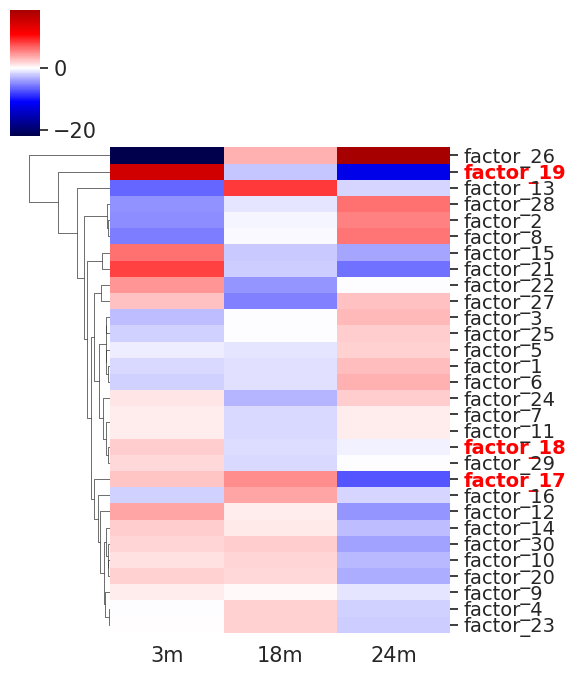

In [14]:
plot_clustermap(coefficients_age, highlighted_factors=['factor_17', 'factor_18', 'factor_19'])

In [15]:
# Step 1: Assign numeric values to the age groups (in the order of the rows in the DataFrame)
age_mapping = {'3m': 3, '18m': 18, '24m': 24}
numeric_ages = coefficients_age.index.map(age_mapping)
correlations = coefficients_age.apply(lambda x: np.corrcoef(numeric_ages, x)[0, 1])
sorted_correlations = correlations.sort_values()
# Display the top 5 negatively and top 5 positively correlated factors
print("Top 5 Negatively Correlated Factors with Age:")
print(sorted_correlations.head(5))

print("\nTop 5 Positively Correlated Factors with Age:")
print(sorted_correlations.tail(5))

Top 5 Negatively Correlated Factors with Age:
factor_21   -1.000000
factor_19   -0.997090
factor_15   -0.992503
factor_12   -0.922622
factor_18   -0.866279
dtype: float64

Top 5 Positively Correlated Factors with Age:
factor_25    0.946770
factor_2     0.951483
factor_8     0.958696
factor_3     0.963535
factor_26    0.994983
dtype: float64


/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:125: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = data_melted.groupby(['Factor', age_column])['Contribution'].median().reset_index()


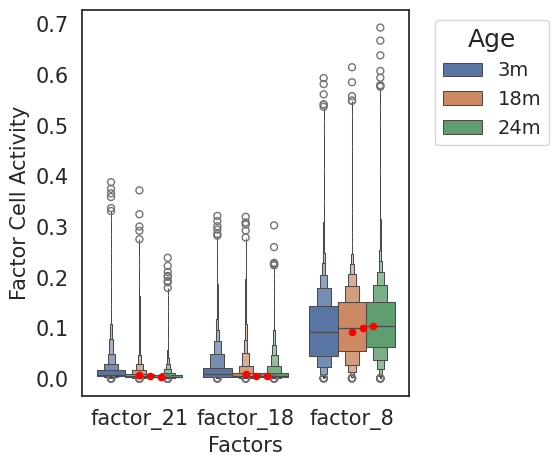

Plot saved as factor_distributions_factor_21_factor_18_factor_8_2024-11-21.pdf


In [16]:
plot_top_factor_distributions(splice_adata, top_factors=["factor_21", "factor_18", "factor_8"], age_column="age", plot_type="boxenplot")

In [17]:
create_age_category(splice_adata)

factors = [f'factor_{i}' for i in range(1, K+1)]

# Call the function to get results
result_table = compare_factors_by_age(splice_adata, factors, cell_type_col='cell_type_grouped')

# Display the result table
print(result_table)

       cell_type     factor  delta_median       p_value  avg_factor_activity  \
0      THYMOCYTE   factor_1     -0.034684  3.426103e-64             0.224235   
1      THYMOCYTE   factor_2      0.048850  2.062469e-42             0.106536   
2      THYMOCYTE   factor_3      0.032485  6.704362e-42             0.085365   
3      THYMOCYTE   factor_4     -0.001942  5.028983e-17             0.012589   
4      THYMOCYTE   factor_5     -0.000733  6.064746e-37             0.004236   
...          ...        ...           ...           ...                  ...   
1105  VALVE CELL  factor_26     -0.000191  7.341313e-01             0.009261   
1106  VALVE CELL  factor_27     -0.001056  9.481281e-05             0.005211   
1107  VALVE CELL  factor_28     -0.000991  4.808162e-01             0.012472   
1108  VALVE CELL  factor_29     -0.000199  1.109411e-01             0.004529   
1109  VALVE CELL  factor_30      0.002217  8.960895e-03             0.017590   

      median_factor_activity  
0       

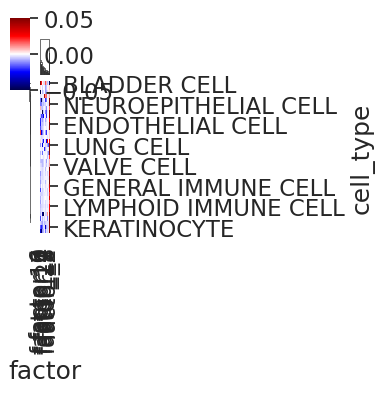

In [18]:
# Step 1: Create a pivot table for delta_median and avg_factor_activity
delta_median_pivot = result_table.pivot(index='cell_type', columns='factor', values='delta_median')
avg_activity_pivot = result_table.pivot(index='cell_type', columns='factor', values='avg_factor_activity')
median_activity_pivot = result_table.pivot(index='cell_type', columns='factor', values='median_factor_activity')

# Step 2: Masking cells with median activity <= 0.001 for delta_median
# mask = avg_activity_pivot < 0.01

# Step 3: Define a colormap that includes black for masked cells
cmap = sns.color_palette("seismic", as_cmap=True)
cmap.set_bad(color='grey')  # Set masked values to black

# Step 3: Cluster the delta_median_pivot to get row and column order
g = sns.clustermap(delta_median_pivot, cmap="seismic", cbar=True, 
                   annot=False, center=0, vmin=-0.05, vmax=0.05, figsize=(4, 4),
                   row_cluster=True, col_cluster=True)

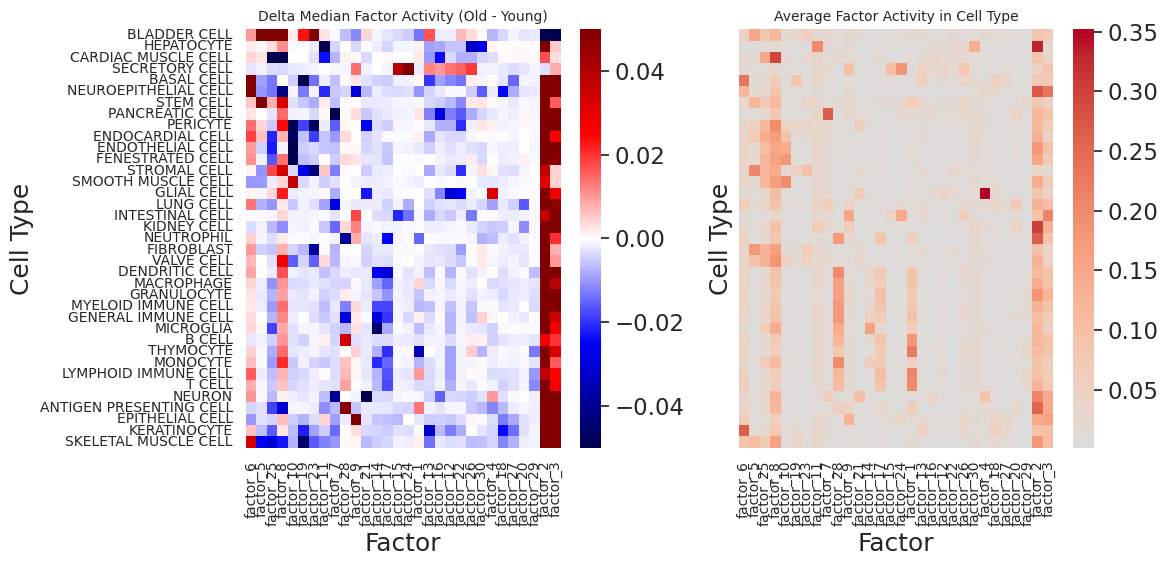

In [19]:
# Extract the cluster order from the clustermap
cell_type_order = g.dendrogram_row.reordered_ind
factor_order = g.dendrogram_col.reordered_ind

# Reindex avg_activity_pivot to match the clustered order of delta_median_pivot
avg_activity_pivot = avg_activity_pivot.iloc[cell_type_order, factor_order]
delta_median_pivot = delta_median_pivot.iloc[cell_type_order, factor_order]  # Reorder this as well

# Step 4: Create a figure for two side-by-side heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Step 5: Plot the delta_median_pivot heatmap with the clustering-based order
sns.heatmap(delta_median_pivot, cmap="seismic", ax=ax1, cbar=True, 
            annot=False, center=0, vmin=-0.05, vmax=0.05, xticklabels=True, yticklabels=True)

# Step 6: Plot the avg_activity_pivot heatmap with the same order as delta_median_pivot
sns.heatmap(avg_activity_pivot, cmap="coolwarm", ax=ax2, cbar=True, 
            annot=False, center=0, vmin=avg_activity_pivot.min().min(), vmax=avg_activity_pivot.max().max(), 
            xticklabels=True, yticklabels=False)  # Show x-axis ticks but hide y-axis ticks

# Step 7: Set titles for the plots
ax1.set_title('Delta Median Factor Activity (Old - Young)', fontsize=10)
ax2.set_title('Average Factor Activity in Cell Type', fontsize=10)

# Step 8: Set x-axis and y-axis labels for the left plot (since it's clustered) 
ax1.set_xticklabels(delta_median_pivot.columns, rotation=90, fontsize=10)
ax1.set_yticklabels(delta_median_pivot.index, rotation=0, fontsize=10)
ax1.set_ylabel("Cell Type")
ax1.set_xlabel("Factor")

# Set x-axis labels for the right plot (factors should be shown)
ax2.set_xticklabels(avg_activity_pivot.columns, rotation=90, fontsize=10)
ax2.set_ylabel("Cell Type")
ax2.set_xlabel("Factor")

# Adjust layout
plt.tight_layout()

# Step 5: Save the figure as a PDF with filename including current date
current_date = datetime.now().strftime("%Y-%m-%d")
filename = f"supp_heatmaps_delta_avg_factors_{current_date}.pdf"
plt.savefig(filename, format='pdf')

plt.show()

### Plot factor distribution by age either in one cell type or across all!

/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:281: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scores, label=f"{age}", color=colors[age], shade=True)
/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:281: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scores, label=f"{age}", color=colors[age], shade=True)
/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:281: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scores, label=f"{age}", color=colors[age], shade=True)


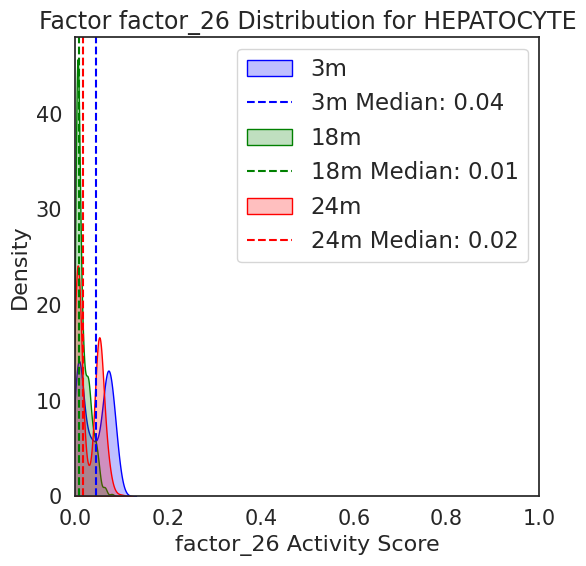

In [20]:
plot_factor_distribution_by_age(splice_adata, "factor_26", "HEPATOCYTE")

/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:281: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scores, label=f"{age}", color=colors[age], shade=True)
/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:281: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scores, label=f"{age}", color=colors[age], shade=True)
/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:281: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scores, label=f"{age}", color=colors[age], shade=True)


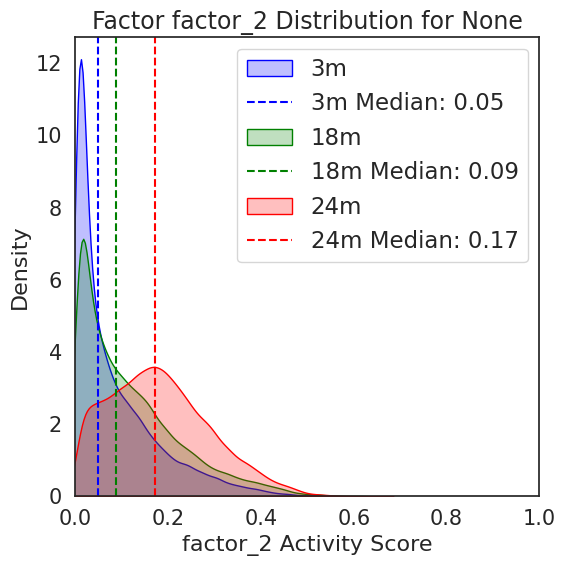

In [21]:
plot_factor_distribution_by_age(splice_adata, "factor_2", None)

### Plot factor distribution across all cells in cell type regardless of age 

/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:232: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(young_scores, label="Young", color="blue", shade=True)
/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:235: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(old_scores, label="Old", color="red", shade=True)


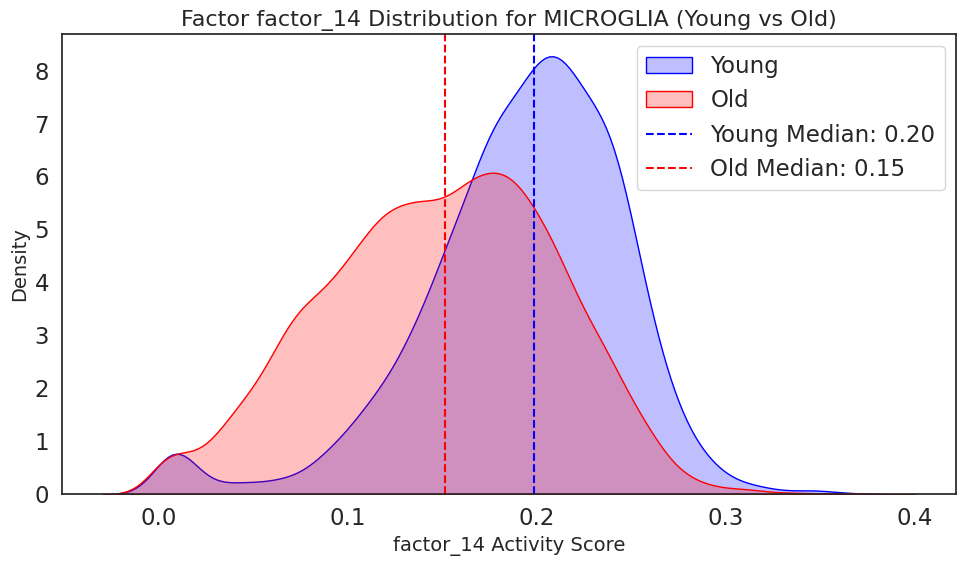

In [22]:
plot_factor_distribution(splice_adata, "MICROGLIA", "factor_14")

In [23]:
# Step 1: Convert age categories to numerical values (3m -> 3, 18m -> 18, 24m -> 24)
age_map = {'3m': 1, '18m': 2, '24m': 3}
splice_adata.obs['age_numeric'] = splice_adata.obs['age'].map(age_map).astype(int)
# Example usage
rmse, coefficients_df = linear_regression_age_prediction(splice_adata, K=30)

Age Prediction RMSE: 0.6865


In [24]:
splice_adata.obs['age_numeric'].values

array([1, 3, 2, ..., 1, 1, 1])

In [25]:
# Sort the DataFrame by coefficient in descending order
coefficients_df = coefficients_df.sort_values(by='Coefficient', ascending=False)

In [26]:
# Select columns that contain "factor" in their name and ensure they are numeric
factor_columns = splice_adata.obs.filter(like='factor')

# Convert the selected factor columns to numeric, if they are not already
for col in factor_columns.columns:
    splice_adata.obs[col] = pd.to_numeric(splice_adata.obs[col], errors='coerce')

# Group by age and calculate the median for these factor columns
age_groups = splice_adata.obs.groupby('age_category')[factor_columns.columns].median()

# Compute the delta between 3m, 18m, and 24m for each factor
deltas = pd.DataFrame({
    'Factor': [f'factor_{i}' for i in range(1, K + 1)],
    'Delta_OY': age_groups.loc['old'] - age_groups.loc['young']
})

coefficients_with_deltas = deltas.merge(coefficients_df)

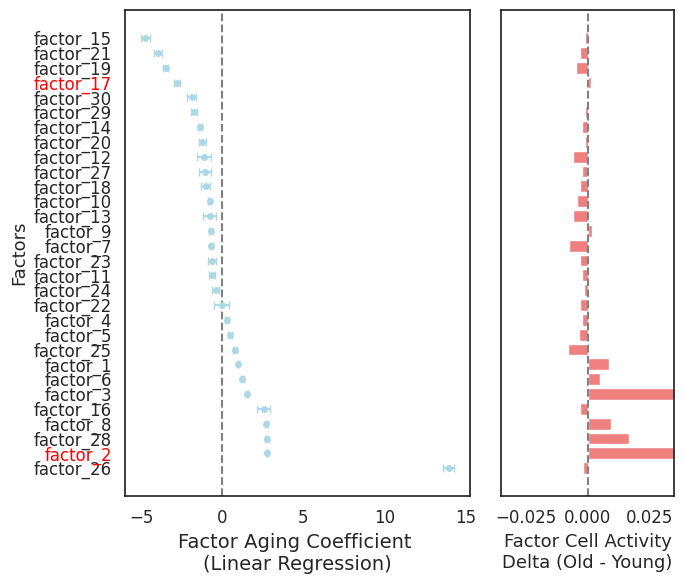

In [27]:
# Set global font size for the entire plot
plt.rcParams.update({'font.size': 12})

# Sort the DataFrame by coefficient in descending order
coefficients_with_deltas = coefficients_with_deltas.sort_values(by='Coefficient', ascending=False)

# Factors to highlight in red
highlight_factors = ['factor_17', 'factor_2']

# Create figure with two subplots (side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 6), gridspec_kw={'width_ratios': [2, 1]}, sharey=True)

# Plot 1: Coefficients with error bars using plt.errorbar
ax1.errorbar(coefficients_with_deltas['Coefficient'], coefficients_with_deltas['Factor'],
             xerr=1.96 * coefficients_with_deltas['Standard Error'], fmt='o', capsize=3, markersize=4, color='lightblue')

# Add a vertical line at x = 0 for reference
ax1.axvline(0, color='gray', linestyle='--')

# Set axis labels and title
ax1.set_xlabel('Factor Aging Coefficient \n(Linear Regression)', fontsize=14)
ax1.set_ylabel('Factors', fontsize=13)

# Highlight specific factors in red
y_ticks = ax1.get_yticklabels()
for tick in y_ticks:
    if tick.get_text() in highlight_factors:
        tick.set_color('red')

# Plot 2: Delta (Old - Young) 
ax2.barh(y=coefficients_with_deltas['Factor'], width=coefficients_with_deltas['Delta_OY'], 
         color='lightcoral', label='Delta YO')
ax2.axvline(0, color='gray', linestyle='--')

# Set axis labels and title for delta plot
ax2.set_xlabel('Factor Cell Activity\nDelta (Old - Young)', fontsize=13)
ax2.set_xlim(-0.035, 0.035)

# Adjust font size of tick labels for both axes
ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)

# Adjust layout
plt.tight_layout()

# Save as pdf 
plt.savefig("linear_regression_factors_aging_with_delta.pdf", format='pdf')

# Show the plot
plt.show()

In [28]:
# Step 1: Adjust p-values using FDR correction (Benjamini-Hochberg)
# Add FDR-adjusted p-values to the cell_type_df
_, result_table['p_value_fdr'] = fdrcorrection(result_table['p_value'])

# Merge the two tables on the 'Factor' column
merged_df = pd.merge(result_table, coefficients_df, how='inner', left_on='factor', right_on='Factor')
threshold = 2 

# Step 1: Filter for significant factors (e.g., p-value < 0.05)
# Step 3: Filter for significant factors based on FDR-adjusted p-values and absolute delta_median > 0.05
significant_factors = merged_df[
    (merged_df['p_value_fdr'] < 0.05) & 
    (merged_df['delta_median'].abs() > 0.05)
]

# Step 2: Group by factor and summarize the number of cell types where the factor is significantly different
factor_summary = significant_factors.groupby('factor').agg(
    num_significant_cell_types=('cell_type', 'count'),  # Count how many cell types show significant changes
    avg_delta_median=('delta_median', 'mean'),          # Average delta_median across all cell types
    min_delta_median=('delta_median', 'min'),           # Minimum delta_median (enriched in young)
    max_delta_median=('delta_median', 'max'),           # Maximum delta_median (enriched in old)
    avg_coefficient=('Coefficient', 'mean')             # Average age coefficient from linear regression
).reset_index()

# Step 3: Identify factors that are commonly enriched (shared across many cell types)
shared_factors = factor_summary[factor_summary['num_significant_cell_types'] > threshold]  # Set a threshold, e.g., > 5 cell types

# Step 4: Identify factors that are strongly enriched in a subset (i.e., large delta in some cell types)
subset_enriched_factors = factor_summary[factor_summary['num_significant_cell_types'] <= threshold]

# Step 5: Sort the results for better readability
shared_factors = shared_factors.sort_values(by='num_significant_cell_types', ascending=False)
subset_enriched_factors = subset_enriched_factors.sort_values(by='avg_delta_median', ascending=False)

# Display the summary
print("Factors Shared Across Many Cell Types:")
print(shared_factors)

print("\nFactors Strongly Enriched in a Subset of Cell Types:")
print(subset_enriched_factors)

Factors Shared Across Many Cell Types:
     factor  num_significant_cell_types  avg_delta_median  min_delta_median  \
3  factor_2                          26          0.083035         -0.072895   
8  factor_3                          14          0.072459         -0.050782   

   max_delta_median  avg_coefficient  
3          0.170482         2.776819  
8          0.129885         1.507918  

Factors Strongly Enriched in a Subset of Cell Types:
       factor  num_significant_cell_types  avg_delta_median  min_delta_median  \
10   factor_6                           1          0.112314          0.112314   
9    factor_5                           2          0.111210          0.077647   
7   factor_25                           1          0.090402          0.090402   
5   factor_23                           1          0.066393          0.066393   
6   factor_24                           1          0.062190          0.062190   
13   factor_9                           1          0.052702       

In [44]:
fact19_age = result_table[result_table["factor"] == "factor_19"].sort_values(by="delta_median")
fact15_age = result_table[result_table["factor"] == "factor_15"].sort_values(by="delta_median")
fact12_age = result_table[result_table["factor"] == "factor_12"].sort_values(by="delta_median")
fact2_age = result_table[result_table["factor"] == "factor_2"].sort_values(by="delta_median")
fact14_age = result_table[result_table["factor"] == "factor_14"].sort_values(by="delta_median")
fact26_age = result_table[result_table["factor"] == "factor_26"].sort_values(by="delta_median")

/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:367: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


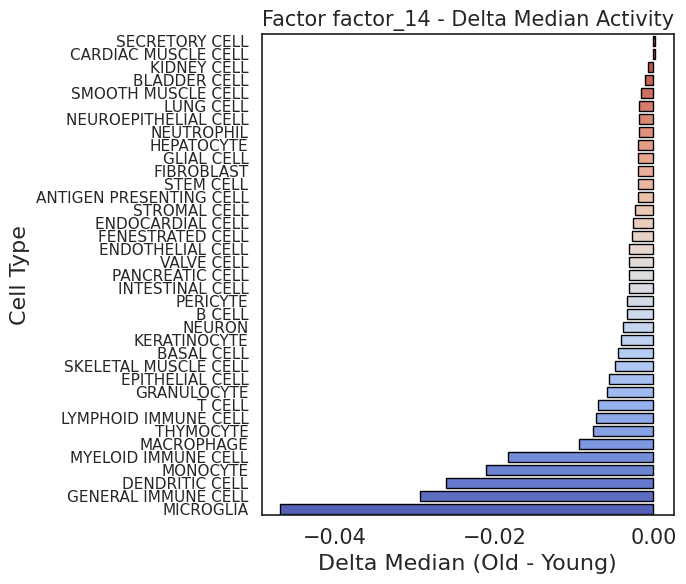

In [30]:
plot_factor_medians(fact14_age, 'factor_14')

/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:367: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


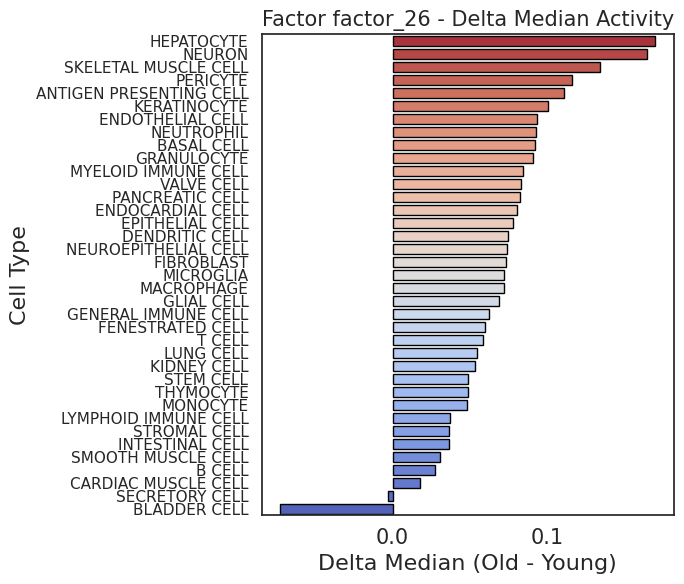

In [31]:
plot_factor_medians(fact26_age, 'factor_26')

/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:367: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


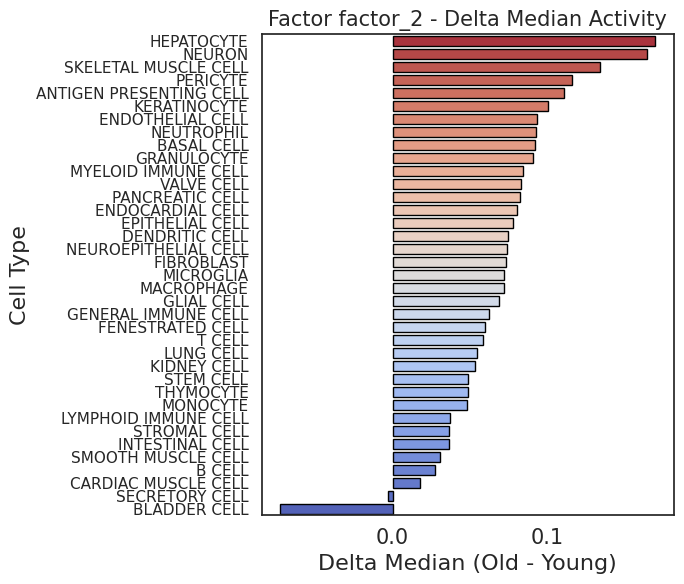

In [32]:
plot_factor_medians(fact2_age, 'factor_2')

In [33]:
# Assuming splice_adata is your AnnData object and the latent factors are stored in `splice_adata.obs`
feature = "cell_type_grouped"
# Call the function
accuracy, coefficients_cell_type = logistic_regression_feature_prediction_simple(splice_adata, feature, K)
# Check the accuracy and coefficients
print(f"Accuracy for {feature}: {accuracy}")
# For each cell type, we will take the top 10 factors by absolute coefficient value.
top_factors_by_cell_type = coefficients_cell_type.apply(lambda x: x.abs().nlargest(5).index.tolist(), axis=1)

Cell_type_grouped Prediction Accuracy: 0.6378
Accuracy for cell_type_grouped: 0.6378060263653484


In [34]:
splice_adata.var_names = splice_adata.var["junction_id"]

### Get UMAP based on assign_post embeddings in splice_data.obs columns with "factor" in them 

In [35]:
# Step 1: Extract the assign_post embeddings from splice_data.obs
# Get all columns with 'factor' in their names
factor_columns = [col for col in splice_adata.obs.columns if 'factor' in col]
embedding = splice_adata.obs[factor_columns].values

# Step 2: Perform UMAP on the factor embeddings
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedding = reducer.fit_transform(embedding)
splice_adata.obsm['X_umap'] = umap_embedding

shuffled_indices = np.random.permutation(splice_adata.obs.index)
shuffled_adata = splice_adata[shuffled_indices, :]

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [36]:
if gtf_used:
    genes_ids = atses[["gene_id", "gene_name"]].drop_duplicates()
    aging_genes = global_aging_genes[global_aging_genes["global_aging_genes"].isin(splice_adata.var["gene_name"])].global_aging_genes.values
    genes_ids['aging_genes'] = genes_ids['gene_name'].isin(combined_genes).map({True: 'yes', False: 'no'})
    genes_ids.aging_genes.value_counts()
    juncs_factors_albf = juncs_factors_albf.merge(genes_ids)

### Look at ALBF scores of junction within a specific factor

In [37]:
# Step 1: Select factor of interest 
factor_int = "Factor 19" 

if gtf_used:

    subset_df = juncs_factors_albf[juncs_factors_albf["Factor"] == factor_int]
    
    # Step 2: Sort first by 'aging_genes' (placing 'yes' first) and then by 'ALBF' in descending order
    sorted_df = subset_df.sort_values(by=["aging_genes", "ALBF"], ascending=[False, False])
    sorted_df = subset_df.sort_values(by="ALBF", ascending=False)
    
    # Step 2: Select the top 50 junctions
    top_50_junctions = sorted_df.head(20)
    
    # Step 3: Create a bar plot to show the top 50 junctions and their ALBF scores
    plt.figure(figsize=(7, 9))
    
    # Define colors based on the aging_genes column ('yes' for aging genes, 'no' for non-aging genes)
    color_palette = {'yes': 'red', 'no': 'blue'}
    
    # Plot the barplot with different colors based on the aging_genes column
    sns.barplot(x="ALBF", y="junction_id", data=top_50_junctions, hue="aging_genes", dodge=False, palette=color_palette)
    
    # Italicize gene names
    italic_font = FontProperties(style='italic')
    
    # Add the gene names as labels for each junction with italic font
    for i in range(top_50_junctions.shape[0]):
        plt.text(top_50_junctions["ALBF"].values[i] + 1, i, 
                 top_50_junctions["gene_name"].values[i], 
                 fontproperties=italic_font, color='black', va="center", fontsize=12)
    
    # Set labels and title
    plt.xlabel("ALBF Score", fontsize=14)
    plt.ylabel("Junction ID", fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{factor_int}_top_junctions.pdf", format='pdf')
    
    # Show the plot
    plt.show()

### Rerun logistic regression to predict age groups comparing splicing vs gene expression based signals

In [38]:
# Assume splice_adata and gene_expression_adata are already loaded and preprocessed
feature_to_predict = 'age'  # Replace target feature

accuracies, aurocs, auprs, models, label_encoder, coefficients_dfs = logistic_regression_feature_prediction(
    splice_adata,
    adata,
    feature=feature_to_predict,
    K=K,
    n_pcs=50,
    test_size=0.2,
    random_state=42
)

print(accuracies)

Age Prediction Accuracy using Splicing Factors: 0.6012
Age Prediction AUROC using Splicing Factors: 0.7796
Age Prediction AUPR using Splicing Factors: 0.6291
Age Prediction Accuracy using Gene Expression PCs: 0.6171
Age Prediction AUROC using Gene Expression PCs: 0.7969
Age Prediction AUPR using Gene Expression PCs: 0.6524
Age Prediction Accuracy using Combined Features: 0.6833
Age Prediction AUROC using Combined Features: 0.8512
Age Prediction AUPR using Combined Features: 0.7352
Age Prediction Accuracy using Tissue Only: 0.4220
Age Prediction AUROC using Tissue Only: 0.5985
Age Prediction AUPR using Tissue Only: 0.4084
{'splicing': 0.6012241054613936, 'gene_expression': 0.617090395480226, 'combined': 0.6833333333333333, 'tissue_only': 0.4219868173258004}


In [39]:
coef_splicing = coefficients_dfs['splicing']
coef_gene_expression = coefficients_dfs['gene_expression']
coef_combined = coefficients_dfs['combined']
coef_tissue_only = coefficients_dfs['tissue_only']

### Calcualte Entropy and Perplexity across Cells

Entropy and Perplexity for each cell (first 10 cells):
[[ 2.804667   16.52157325]
 [ 2.03158034  7.62612871]
 [ 2.579343   13.18847044]
 [ 2.29862422  9.96046961]
 [ 2.57370892 13.11437448]
 [ 2.46867454 11.80678707]
 [ 2.72339122 15.2318895 ]
 [ 3.07304501 21.60759793]
 [ 2.81048881 16.61803927]
 [ 2.41308884 11.1684053 ]]


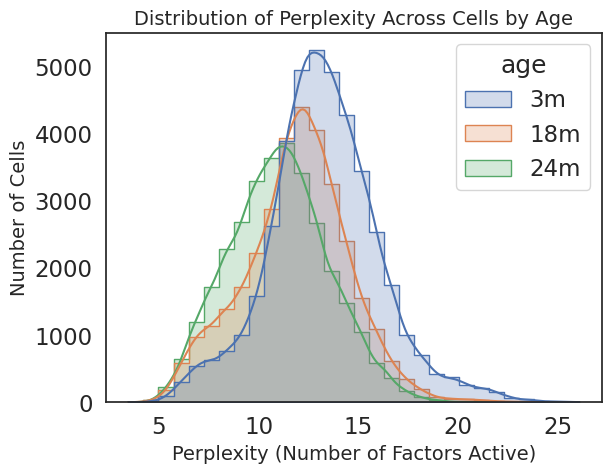

In [40]:
# Calculate entropy for each cell (each row sums to 1)
entropy = -np.sum(assign_post * np.log(assign_post + 1e-12), axis=1)  # Small epsilon added for numerical stability

# Calculate perplexity for each cell
perplexity = np.exp(entropy)

# Combine results for better readability
results = np.column_stack((entropy, perplexity))

# Display the first few results
print("Entropy and Perplexity for each cell (first 10 cells):")
print(results[:10])

splice_adata.obs["perplexity"] = perplexity
splice_adata.obs["entropy"] = entropy

# Assuming `perplexity` is already added to `splice_adata.obs` as a column
sns.histplot(data=splice_adata.obs, x="perplexity", hue="age", bins=30, kde=True, element="step")
plt.xlabel("Perplexity (Number of Factors Active)", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Distribution of Perplexity Across Cells by Age", fontsize=14)
plt.show()

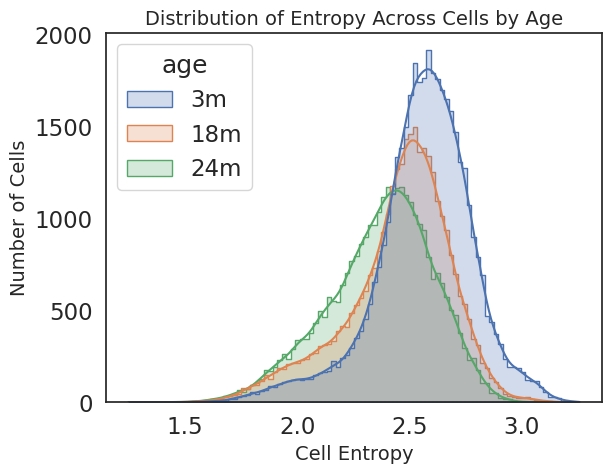

In [41]:
# Assuming `perplexity` is already added to `splice_adata.obs` as a column
sns.histplot(data=splice_adata.obs, x="entropy", hue="age", bins=100, kde=True, element="step")
plt.xlabel("Cell Entropy", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Distribution of Entropy Across Cells by Age", fontsize=14)
plt.show()

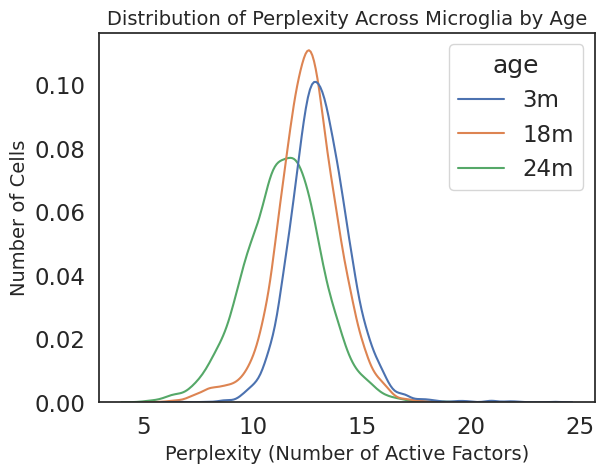

In [42]:
microglia_only = splice_adata.obs[splice_adata.obs["cell_type_grouped"] == "MICROGLIA"]
sns.kdeplot(data=microglia_only, x="perplexity", hue="age")
plt.xlabel("Perplexity (Number of Active Factors)", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Distribution of Perplexity Across Microglia by Age", fontsize=14)
plt.show()

/scratch/ipykernel_24950/2709389559.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_perplexity = splice_adata.obs.groupby(['cell_type_grouped', 'age'])['perplexity'].median().unstack()


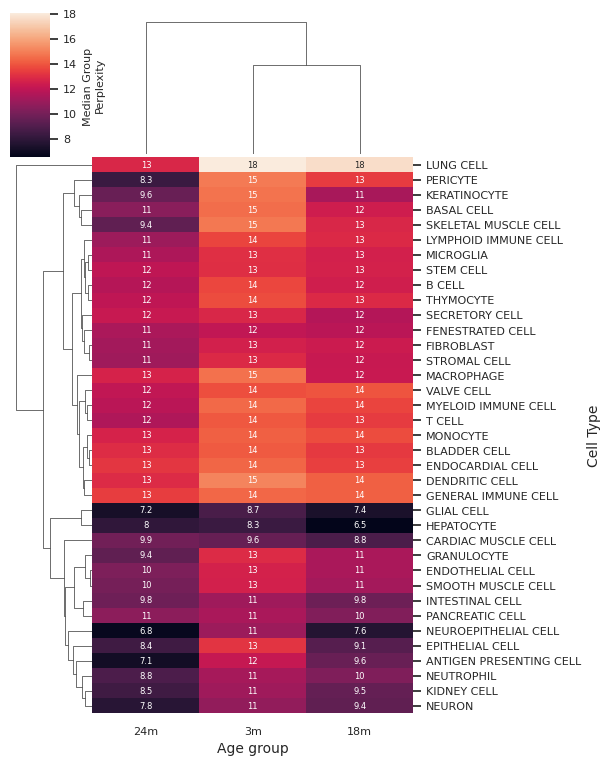

In [43]:
# Calculate median perplexity for each cell type and age category
median_perplexity = splice_adata.obs.groupby(['cell_type_grouped', 'age'])['perplexity'].median().unstack()

# Make font size for ERVERYTHING smaller!
g = sns.clustermap(median_perplexity, xticklabels=1, yticklabels=1, 
               annot_kws={"size": 6},  # Smaller font size for annotations
               annot=True, figsize=(8, 8), 
               cbar_kws={'label': 'Median Group \nPerplexity'})

# Set font size for row and column tick labels
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, fontsize=8)
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)

# Customize the color legend font size
g.cax.yaxis.label.set_size(8)
g.cax.tick_params(labelsize=8)

# Set axis labels with smaller font size
g.ax_heatmap.set_xlabel("Age group", fontsize=10)
g.ax_heatmap.set_ylabel("Cell Type", fontsize=10)

plt.show()

### Some of these cell types are very broad like "Lung cell", "Bladder cell", "Kidney cell" some can still have immune cells in them?

### Calcualte Entropy and Perplexity across Junctions!

In [52]:
# remove index names from splice_adata.var 
splice_adata.var = splice_adata.var.reset_index(drop=True)

In [75]:
# Calculate entropy for each junction (columns represent factors for each junction)
entropy = -np.sum(psi_learned.T * np.log(psi_learned.T + 1e-12), axis=1)

# Calculate perplexity for each junction
perplexity = np.exp(entropy)

# Combine results for better readability
results = np.column_stack((entropy, perplexity))

# Make into dataframe with columns junction_entropt and junction_perplexity
junc_results = pd.DataFrame(results, columns=["junction_entropy", "junction_perplexity"])
junc_results["junction_id"] = splice_adata.var["junction_id"]
junc_results.sort_values(by="junction_perplexity", ascending=False, inplace=True)
junc_results

,junction_entropy,junction_perplexity,junction_id
40343,11.033770,61930.589367,chr4_127036649_127036931_+
7974,11.033555,61917.279562,chr11_94338521_94339552_+
33547,11.033191,61894.801268,chr2_157109532_157110547_-
20937,11.029227,61649.883985,chr17_30228878_30274853_-
51229,11.024140,61337.070348,chr7_126493376_126493552_-
...,...,...,...
22273,0.042492,1.043408,chr17_35267221_35754626_+
11790,0.042370,1.043281,chr13_55322065_55324924_-
22217,0.042287,1.043194,chr17_35263902_35263990_+
33752,0.040498,1.041329,chr2_164839804_164855018_+


In [ ]:
splice_adata.var = splice_adata.var.merge(junc_results, on="junction_id")

In [73]:
# drop these columns from splice_adat.var junction_entropy_x	junction_perplexity_x	junction_entropy_y	junction_perplexity_y
splice_adata.var = splice_adata.var.drop(columns=["junction_entropy_x", "junction_perplexity_x", "junction_entropy_y", "junction_perplexity_y"])

In [ ]:
# drop Junction_Index from albf_scores 
albf_scores = albf_scores.drop(columns=["Junction_Index"])

In [84]:
albf_scores

,Factor,ALBF,junction_id_index
0,Factor 1,4.080916,0
1,Factor 1,1.169916,1
2,Factor 1,4.671865,2
3,Factor 1,1.452341,3
4,Factor 1,0.015566,4
...,...,...,...
1946455,Factor 30,3.199451,64877
1946456,Factor 30,1.205747,64878
1946457,Factor 30,0.068229,64879
1946458,Factor 30,0.754349,64880


In [86]:
splice_adata.var.sort_values(by="junction_id_index", ascending=False, inplace=True)
splice_adata.var.sort_values(by="junction_perplexity", ascending=True, inplace=False)

,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,factor_10,...,factor_30,junction_id_index,junction_id,num_cells_with_junc,total_read_counts,Cluster,CountJuncs,old_index,junction_entropy,junction_perplexity
21649,0.000088,0.000099,0.000097,0.000140,0.000124,0.000077,0.000094,0.000075,0.000119,0.000101,...,0.000141,21649,chr17_34314225_34334264_-,677,1074,25468,85,24221,0.037090,1.037786
33752,0.000093,0.000089,0.000112,0.000150,0.000119,0.000073,0.000132,0.000067,0.000107,0.000166,...,0.000123,33752,chr2_164839804_164855018_+,162,1386,2621,54,37548,0.040498,1.041329
22217,0.000085,0.000026,0.000086,0.000084,0.000126,0.000102,0.000203,0.000080,0.000112,0.000248,...,0.000065,22217,chr17_35263902_35263990_+,116,9964,24862,456,24832,0.042287,1.043194
11790,0.000103,0.000086,0.000074,0.000168,0.000138,0.000131,0.000168,0.000073,0.000151,0.000150,...,0.000124,11790,chr13_55322065_55324924_-,459,642,20980,128,13018,0.042370,1.043281
22273,0.000208,0.000144,0.000145,0.000144,0.000157,0.000175,0.000171,0.000105,0.000135,0.000395,...,0.000130,22273,chr17_35267221_35754626_+,113,1036,24862,456,24892,0.042492,1.043408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51229,0.392033,0.371341,0.398413,0.366319,0.379989,0.386184,0.373608,0.389902,0.383536,0.380337,...,0.386356,51229,chr7_126493376_126493552_-,5917,68127,12500,2,56568,11.024140,61337.070348
20937,0.363189,0.376507,0.361464,0.363533,0.359091,0.363059,0.362738,0.364640,0.371100,0.351729,...,0.360839,20937,chr17_30228878_30274853_-,6562,205568,25405,7,23416,11.029227,61649.883985
33547,0.365485,0.361999,0.361313,0.366963,0.366198,0.366468,0.378308,0.357925,0.362411,0.380589,...,0.364980,33547,chr2_157109532_157110547_-,15939,1197168,3709,8,37325,11.033191,61894.801268
7974,0.381951,0.363249,0.370597,0.367249,0.382088,0.374700,0.381400,0.377973,0.380830,0.371331,...,0.365926,7974,chr11_94338521_94339552_+,8541,203439,17771,2,8785,11.033555,61917.279562


### Calcualte Entropy and Perplexity across Factors to see how many cell types they are active in ?

### Look at factor-factor correlations in terms of cell usage - also do this usage junction PSI

In [87]:
splice_adata.obs[factor_columns].shape

(106199, 30)

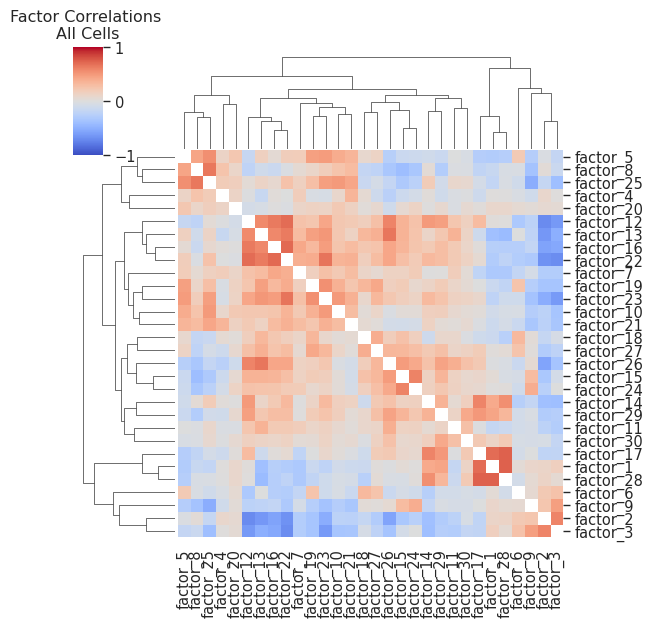

In [88]:
factor_corr_spearman_all = splice_adata.obs[factor_columns].corr(method='spearman')

# Create a mask to hide the diagonal
mask = np.eye(len(factor_corr_spearman_all), dtype=bool)

# Set overall font size smaller using Seaborn context
sns.set_context("paper", font_scale=1.2)  # Adjust `font_scale` for smaller/larger font

# Create a clustermap with masked diagonal
g = sns.clustermap(
    factor_corr_spearman_all, annot=False, cmap='coolwarm', center=0, mask=mask,
    yticklabels=1, xticklabels=1, figsize=(6, 6), vmin=-1, vmax=1)

plt.title("Factor Correlations \nAll Cells")
plt.show()

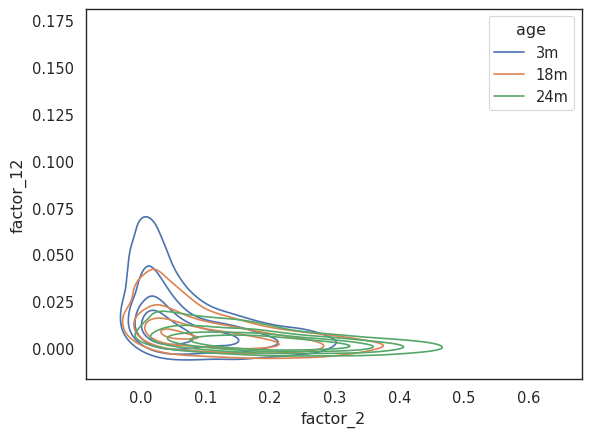

In [89]:
# let's look at correlation of cells activities among factor_1 and factor_13 
# make a scatter plot of factor_1 vs factor_13

# Plot scatterplot with density visualization
sns.kdeplot(
    data=splice_adata.obs.sample(10000),
    x="factor_2",
    y="factor_12",
    levels=5, thresh=.2,
    hue="age")
plt.show()

### Look at factor-factor correlations using junction PSI values...

In [90]:
psi_learned_df = pd.DataFrame(psi_learned).T
psi_learned_df.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.007198,0.005612,0.256293,0.012831,0.336807,0.173190,0.012082,0.758712,0.015302,0.157428,...,0.360932,0.024729,0.749809,0.022929,0.741315,0.671670,0.533275,0.180377,0.019599,0.006205
1,0.062857,0.028333,0.594633,0.024982,0.002812,0.182539,0.013234,0.031509,0.900291,0.400033,...,0.005529,0.122550,0.002481,0.850162,0.092087,0.924005,0.641790,0.893561,0.034451,0.026539
2,0.006360,0.003883,0.610359,0.011409,0.555360,0.363223,0.017259,0.798056,0.007423,0.121428,...,0.015268,0.014131,0.670795,0.018601,0.246752,0.530579,0.098002,0.638086,0.021488,0.011087
3,0.023381,0.096311,0.012002,0.061914,0.034785,0.161495,0.114232,0.083277,0.009987,0.090193,...,0.383587,0.259242,0.009278,0.182179,0.003956,0.014093,0.214300,0.242855,0.142293,0.116176
4,0.879055,0.875276,0.858154,0.869171,0.878738,0.876618,0.872611,0.859998,0.855964,0.872785,...,0.848586,0.872096,0.873545,0.871854,0.878354,0.059341,0.849376,0.877419,0.855939,0.856744


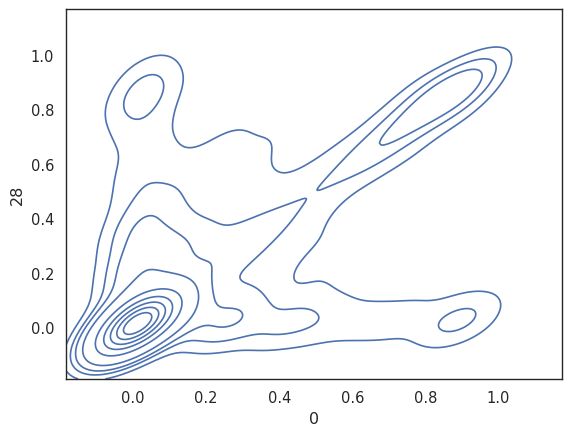

In [91]:
sns.kdeplot(
    data=psi_learned_df.sample(5000),x=0, y=28)
plt.show()

In [92]:
factor_corr_spearman_juncs = psi_learned_df.corr(method='spearman')

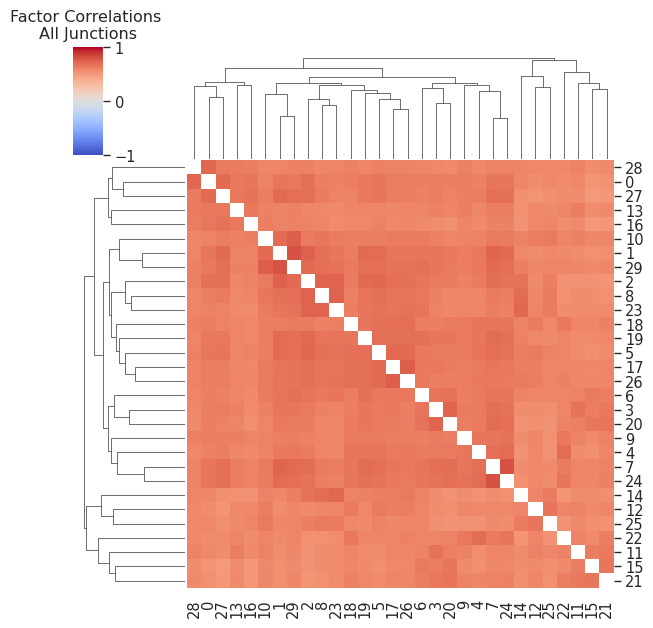

In [93]:
# Create a mask to hide the diagonal
mask = np.eye(len(factor_corr_spearman_juncs), dtype=bool)

# Set overall font size smaller using Seaborn context
sns.set_context("paper", font_scale=1.2)  # Adjust `font_scale` for smaller/larger font

# Create a clustermap with masked diagonal
g = sns.clustermap(
    factor_corr_spearman_juncs, annot=False, cmap='coolwarm', center=0, mask=mask,
    yticklabels=1, xticklabels=1, figsize=(6, 6), vmin=-1, vmax=1)

plt.title("Factor Correlations \nAll Junctions")
plt.show()

### Look at junction annotations!

In [94]:
# junction_id  Cluster  usage_ratio
splice_adata_var = juncs_factors_albf[["junction_id", "Cluster"]].drop_duplicates()
splice_adata_var["usage_ratio"] = 0

# Convert junction_ids
splice_junctions = ja.convert_junction_ids(splice_adata_var)

In [95]:
splice_junctions[0]

{'chrom': 'chr10',
 'start': 100080130,
 'end': 100080856,
 'name': 'junction_1',
 'strand': '+',
 'usage_ratio': 0}

In [96]:
# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

100%|██████████| 64882/64882 [27:32<00:00, 39.26it/s]  


In [97]:
print(junction_annotation_results[1])

{'junction': 'chr10:100080130-100087346', 'strand': '+', 'label_5_prime': "annotated on 5'", 'label_3_prime': "annotated on 3'", 'position_off_5_prime': 0, 'position_off_3_prime': 1, 'transcripts': ['ENSMUST00000105283.8', 'ENSMUST00000020129.7']}


In [99]:
junction_annotation_results_df = pd.DataFrame(junction_annotation_results)

# if label_5_prime is "annotated on 5'" or label_3_prime is "annotated on 3'", then add annotation columns where values would be "one side" if both then "both sides" and if none then "none"
junction_annotation_results_df["annotation"] = "none"
junction_annotation_results_df.loc[(junction_annotation_results_df["label_5_prime"] == "annotated on 5'"), "annotation"] = "one side"
junction_annotation_results_df.loc[(junction_annotation_results_df["label_3_prime"] == "annotated on 3'"), "annotation"] = "one side"
# now check if both are annotated
junction_annotation_results_df.loc[(junction_annotation_results_df["label_5_prime"] == "annotated on 5'") & (junction_annotation_results_df["label_3_prime"] == "annotated on 3'"), "annotation"] = "both sides"
junction_annotation_results_df.annotation.value_counts()

annotation
both sides    45842
none          14566
one side       4474
Name: count, dtype: int64

In [100]:
# save junction_annotation_results_df to file 
junction_annotation_results_df.to_csv("junction_annotation_results_df.csv")

In [101]:
junction_annotation_results_df

,junction,strand,label_5_prime,label_3_prime,position_off_5_prime,position_off_3_prime,transcripts,annotation
0,chr10:100080130-100080856,+,annotated on 5',annotated on 3',0.0,1.0,"[ENSMUST00000105283.8, ENSMUST00000020129.7]",both sides
1,chr10:100080130-100087346,+,annotated on 5',annotated on 3',0.0,1.0,"[ENSMUST00000105283.8, ENSMUST00000020129.7]",both sides
2,chr10:100080940-100087346,+,annotated on 5',annotated on 3',0.0,1.0,[ENSMUST00000105283.8],both sides
3,chr10:100478022-100485050,-,annotated on 5',annotated on 3',1.0,0.0,"[ENSMUST00000058154.14, ENSMUST00000130883.1, ...",both sides
4,chr10:100478022-100487161,-,annotated on 5',annotated on 3',1.0,0.0,"[ENSMUST00000058154.14, ENSMUST00000130883.1, ...",both sides
...,...,...,...,...,...,...,...,...
64877,chrY:90819840-90820595,+,unannotated on 5',unannotated on 3',NaN,NaN,[],none
64878,chrY:90820214-90820448,-,unannotated on 5',unannotated on 3',NaN,NaN,[],none
64879,chrY:90837279-90838776,-,unannotated on 5',unannotated on 3',NaN,NaN,[],none
64880,chrY:90837520-90841656,+,annotated on 5',annotated on 3',0.0,1.0,[ENSMUST00000189352.1],both sides


In [103]:
# add original junction_id to the junction_annotation_results_df
junction_annotation_results_df["junction_id"] = splice_adata_var["junction_id"].values

In [104]:
# add annotation to splice_adata.var 
splice_adata.var = splice_adata.var.merge(junction_annotation_results_df, on="junction_id")

/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:125: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = data_melted.groupby(['Factor', age_column])['Contribution'].median().reset_index()


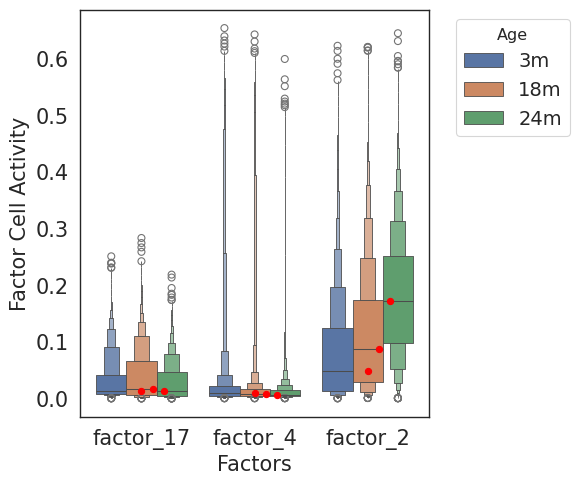

Plot saved as factor_distributions_factor_17_factor_4_factor_2_2024-11-21.pdf


In [105]:
plot_top_factor_distributions(splice_adata, top_factors=["factor_17", "factor_4", "factor_2"], age_column="age", plot_type="boxenplot")

In [106]:
# now let's find top 10% of junctions with highest ALBF scores for factor 2
top_10_percent = int(0.1 * len(splice_adata.var))

# get percent of top junctions that are annotated (both sides) vs (vs one side) vs unannotated for each factor
junc_anno_factors = {}
factor_columns

for factor in factor_columns:
    top_junctions = splice_adata.var.sort_values(by=factor, ascending=False).head(top_10_percent)
    junc_anno_factors[factor] = top_junctions.annotation.value_counts()
    
# convert to dataframe
junc_anno_factors_df = pd.DataFrame(junc_anno_factors).T
junc_anno_factors_df

# get the percentage of annotated junctions for each factor 
junc_anno_factors_df["annotated_percent"] = junc_anno_factors_df["both sides"] / top_10_percent * 100
# get the percentage of unannotated junctions for each factor
junc_anno_factors_df["unannotated_percent"] = junc_anno_factors_df["none"] / top_10_percent * 100
# get the percentage of junctions annotated on one side for each factor
junc_anno_factors_df["one_side_percent"] = junc_anno_factors_df["one side"] / top_10_percent * 100

/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/utilities.py:125: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = data_melted.groupby(['Factor', age_column])['Contribution'].median().reset_index()


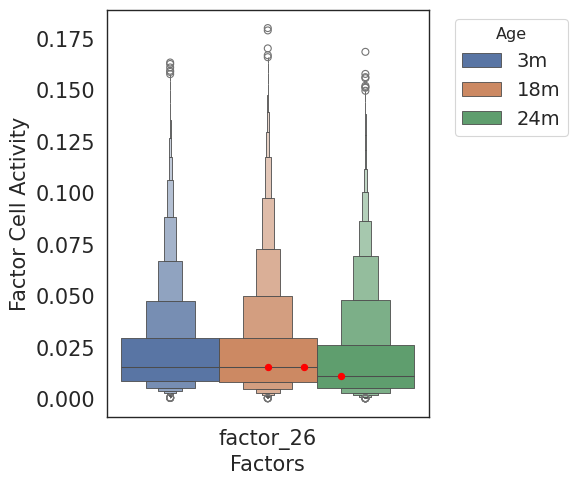

Plot saved as factor_distributions_factor_26_2024-11-21.pdf


In [108]:
plot_top_factor_distributions(splice_adata, top_factors=["factor_26"], age_column="age", plot_type="boxenplot")

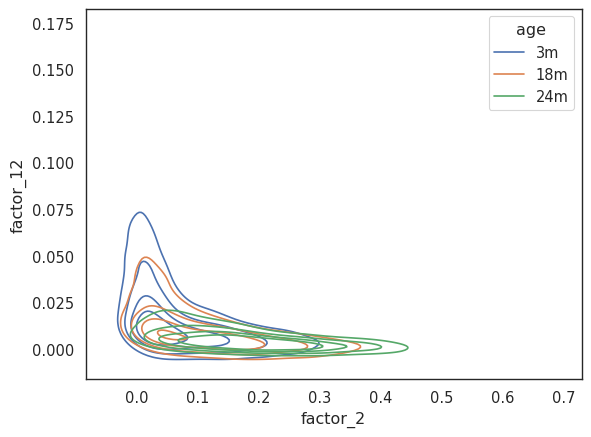

In [110]:
sns.kdeplot(
    data=splice_adata.obs.sample(10000),
    x="factor_2",
    y="factor_12",
    levels=5, thresh=.2,
    hue="age")
plt.show()

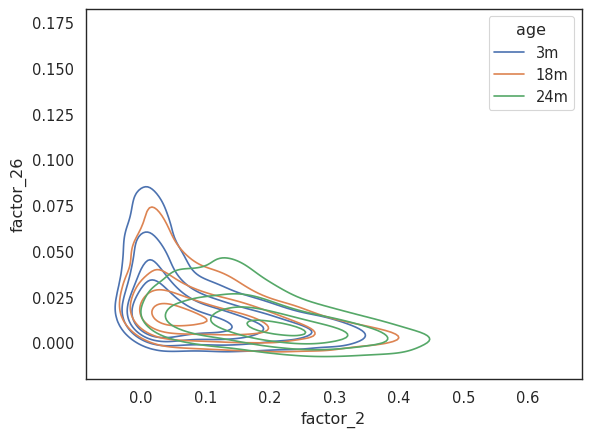

In [111]:
sns.kdeplot(
    data=splice_adata.obs.sample(10000),
    x="factor_2",
    y="factor_26",
    levels=5, thresh=.2,
    hue="age")
plt.show()

In [112]:
# keep just the columns that have "factor" in them and melt the table 
coef_splicing_df = coef_splicing.filter(like="factor").reset_index().melt(id_vars="index", var_name="factor", value_name="count")
# rename columns to age group, factor and coefficient 
coef_splicing_df.columns = ["age_group", "factor", "coefficient"]
# sort by absolute coefficient value
coef_splicing_df = coef_splicing_df.sort_values(by="coefficient", ascending=False)
coef_splicing_df

,age_group,factor,coefficient
76,24m,factor_26,18.839273
56,3m,factor_19,13.556761
36,18m,factor_13,8.458125
62,3m,factor_21,8.067243
41,3m,factor_14,6.032222
...,...,...,...
58,24m,factor_20,-6.649938
49,24m,factor_17,-6.721617
38,3m,factor_13,-7.242106
55,24m,factor_19,-10.306430


In [120]:
# let's extract junction_id and perxplecity from splice_adata.var and merge with juncs_factors_albf
splice_adata_var = splice_adata.var[["junction_id", "junction_perplexity"]].drop_duplicates()
juncs_factors_albf = juncs_factors_albf.merge(splice_adata_var, on="junction_id")

In [121]:
juncs_factors_albf.sort_values(by="ALBF", ascending=False)

,junction_id,Cluster,junction_id_index,Factor,Junction_Index,ALBF,junction_perplexity
800473,chr19_4343241_4345517_-,26913,26682,Factor 14,26682,4.605170e+01,1.641393
676732,chr17_35910093_35910202_+,24863,22557,Factor 23,22557,4.605170e+01,1.096628
1059015,chr2_32671507_32672217_+,1934,35300,Factor 16,35300,4.605170e+01,320.989856
691013,chr17_46814038_46824449_-,25550,23033,Factor 24,23033,4.605170e+01,1.447028
1374397,chr5_142905476_142905563_-,8913,45813,Factor 8,45813,4.605170e+01,1502.910751
...,...,...,...,...,...,...,...
420289,chr14_54259319_54261625_+,21518,14009,Factor 20,14009,1.357529e-08,1177.161300
1579253,chr7_143053066_143062492_+,11621,52641,Factor 24,52641,7.916245e-09,857.709870
1781164,chr9_113656207_113657085_-,15746,59372,Factor 5,59372,6.481726e-09,9929.380895
377741,chr13_81657936_81665004_+,20620,12591,Factor 12,12591,3.201369e-09,5092.237959


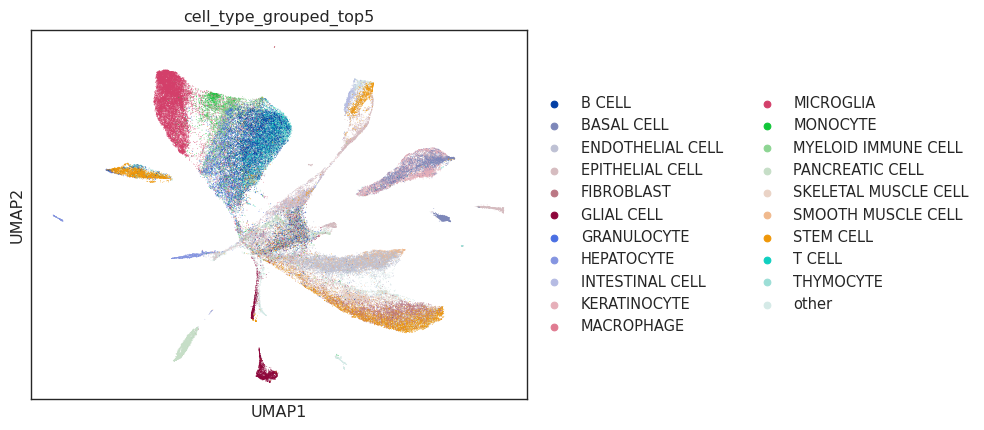

In [134]:
# let's find top 5 cell_types and label them and all other cells make grey 
top_5_cell_types = splice_adata.obs["cell_type_grouped"].value_counts().head(20).index.values

# create a new column in splice_adata.obs called "cell_type_grouped_top5" and label the top 5 cell types and all other cell types as "other"
splice_adata.obs["cell_type_grouped_top5"] = splice_adata.obs["cell_type_grouped"].apply(lambda x: x if x in top_5_cell_types else "other")

# make umap plot with cell_type_grouped_top5 as color
sc.pl.umap(splice_adata, color=["cell_type_grouped_top5"])

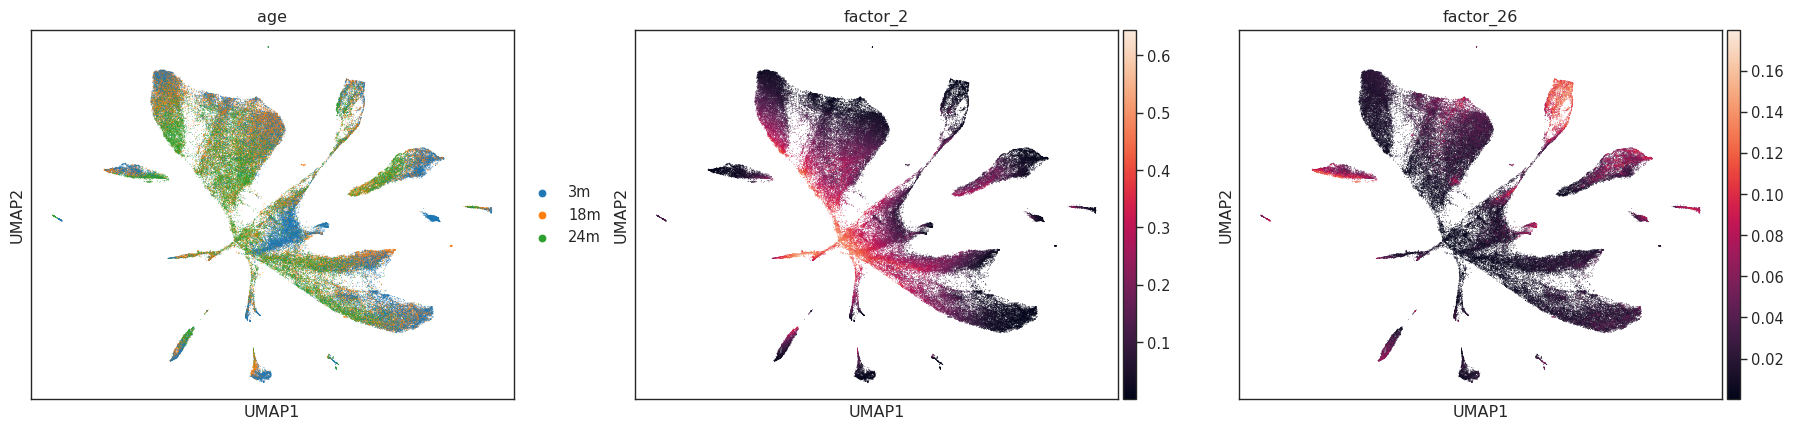

In [135]:
sc.pl.umap(splice_adata, color=["age", "factor_2", "factor_26"])

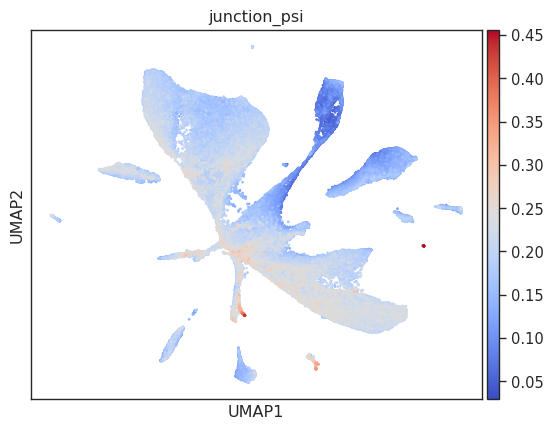

In [122]:
junction_id_index = 35300  
splice_adata.obs['junction_psi'] = splice_adata.layers['new_junc_ratio'][:, junction_id_index].flatten()

# Step 2: Plot UMAP with junction usage ratio
sc.pl.umap(splice_adata, color=['junction_psi'], color_map='coolwarm', size=15)

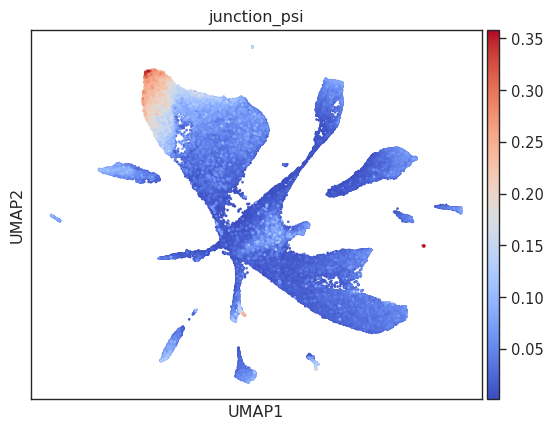

In [119]:
junction_id_index = 26682  
splice_adata.obs['junction_psi'] = splice_adata.layers['new_junc_ratio'][:, junction_id_index].flatten()

# Step 2: Plot UMAP with junction usage ratio
sc.pl.umap(splice_adata, color=['junction_psi'], color_map='coolwarm', size=15)

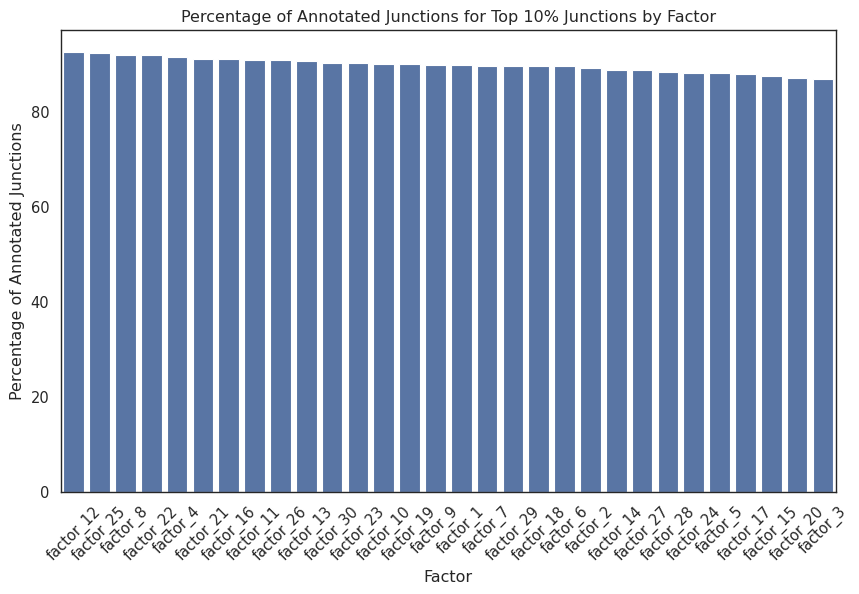

In [140]:
# make barplot ordered by annotated_percent in decreasing order 
junc_anno_factors_df.sort_values(by="annotated_percent", ascending=False, inplace=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=junc_anno_factors_df, x=junc_anno_factors_df.index, y="annotated_percent")
plt.xticks(rotation=45)
plt.xlabel("Factor")
plt.ylabel("Percentage of Annotated Junctions")
plt.title("Percentage of Annotated Junctions for Top 10% Junctions by Factor")
plt.show()

### Fgfr2 specific visualization of mutually exclusive exons

In [ ]:
splice_adata_var = splice_adata_var[splice_adata_var["Cluster"] == 26488] # Fgfr2 related cluster
# Let's limit to just Fgfr2 mutually exclusive exons isoforms 120187 and 122054
unique_transcripts = ["ENSMUST00000120187.8", "ENSMUST00000122054.7"] # Fgfr2 mutually exclusive exons

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(unique_transcripts, db)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)
junc_annots = ja.check_junction_annotation(splice_junctions, db)

In [ ]:
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start, region_end, base_width=10, trans_height=0.3, show_usage=False, show_junc_lines=True)

In [ ]:
junction_id_index = 42968  #chr7_130196374_130198418_- --> 	 
splice_adata.obs['junction_psi'] = splice_adata.layers['new_junc_ratio'][:, junction_id_index].flatten()

# Step 2: Plot UMAP with junction usage ratio
sc.pl.umap(splice_adata, color=['junction_psi'], color_map='coolwarm', size=15)

In [ ]:
junction_id_index = 42969 # chr7_130196374_130199757_- # Replace with the actual index for the junction of interest
splice_adata.obs['junction_psi'] = splice_adata.layers['new_junc_ratio'][:, junction_id_index].flatten()

# Step 2: Plot UMAP with junction usage ratio
sc.pl.umap(splice_adata, color=['junction_psi'], color_map='coolwarm', size=15)